In [47]:
# Import required libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import geopandas as gpd
from shapely.geometry import mapping

# Import XSeas package
from xseas import SeasonDetect
from xseas.utils import day_of_year_to_date

# Path configuration
import os
from pathlib import Path

# Set global matplotlib style for publication-quality figures
mpl.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

In [48]:
import yaml

with open('paths.local.yaml', 'r') as file:
    paths = yaml.safe_load(file)

FIGURES_DIR = Path(paths['FIGURES_DIR'])
SUPP_FIGURES_DIR = Path(paths['SUPP_FIGURES_DIR'])
WORKING_FOLDER = Path(paths['WORKING_FOLDER'])

In [49]:
# Ensure figures directory exists
#FIGURES_DIR.mkdir(exist_ok=True)

# Define key paths
SHAPEFILES_PATH = WORKING_FOLDER / 'shapefiles'
REFERENCES_PATH = WORKING_FOLDER / 'references'
CONFIG_FILE = 'three_seas_all_vars.yaml'

In [50]:
# Initialize SeasonDetect project with relative paths
project = SeasonDetect(str(WORKING_FOLDER), CONFIG_FILE)

✅ Using existing XSeas project at: /Users/jacopograssi/Documents/XSeas/working_folder
⚠️  Recommended key missing: parameters_projections


In [51]:
if not os.path.exists(str(project.clustering_path)):
    breakpoints, error_history, silhouette_scores = project.perform_clustering()

In [52]:
# Load clustering results and reference data
clustering_results = xr.open_dataset(project.clustering_path).breakpoints
clustering_results = clustering_results.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
clustering_results.rio.write_crs("epsg:4326", inplace=True)

# Load reference monsoon dates from IMD
reference_file = REFERENCES_PATH / 'monsoon_dates.nc'
reference_results = xr.open_dataset(reference_file)
reference_results = reference_results.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
reference_results.rio.write_crs("epsg:4326", inplace=True)

print(f"Clustering results shape: {clustering_results.shape}")
print(f"Reference data shape: {reference_results.date.shape}")
print(f"Spatial extent: {clustering_results.lon.min().values:.1f}°E to {clustering_results.lon.max().values:.1f}°E, "
      f"{clustering_results.lat.min().values:.1f}°N to {clustering_results.lat.max().values:.1f}°N")

Clustering results shape: (36, 36, 3)
Reference data shape: (27, 29, 2)
Spatial extent: 65.0°E to 100.0°E, 5.0°N to 40.0°N


In [53]:
# Regional analysis configuration
# Define climate regions for comparative analysis
reg_codes = ['HKK', 'him', 'central_india', 'southwest_india']
reg_names = ['Hindu Kush Karakoram', 'Himalaya', 'Central India', 'Southwest India']

# Color scheme for publication (colorblind-friendly palette)
colors = ['#E69F00', '#009E73', '#D55E00', '#0072B2']
positions = [-0.3, -0.1, 0.1, 0.3]  # Box plot positions for each region

print(f"Analyzing {len(reg_codes)} climate regions:")
for code, name in zip(reg_codes, reg_names):
    print(f"  - {name} ({code})")

Analyzing 4 climate regions:
  - Hindu Kush Karakoram (HKK)
  - Himalaya (him)
  - Central India (central_india)
  - Southwest India (southwest_india)


In [54]:
import numpy as np
import matplotlib.pyplot as plt

def fill_annular_sector(ax, start, end, r_inner, r_outer,
                        *, degrees=True, n=200, pad=0.0, **kwargs):
    """
    Riempie un settore anulare [start,end] con raggi [r_inner,r_outer] su assi polari.
    
    Parametri
    ---------
    ax : matplotlib.axes._axes.Axes (projection='polar')
    start, end : float
        Angoli di inizio/fine del settore. In gradi se degrees=True, altrimenti radianti.
    r_inner, r_outer : float
        Raggi interno ed esterno del settore.
    degrees : bool
        Se True, 'start' ed 'end' sono in gradi.
    n : int
        Numero di punti per campionare l'arco.
    pad : float
        Padding angolare (stessa unità di 'start'/'end'): positivo “stringe” l’arco
        su entrambi gli estremi. Utile per simulare il tuo ±0.01 rad.
    **kwargs : dict
        Passato a ax.fill (es. color='crimson', alpha=0.2, zorder=0.3).
    """
    if degrees:
        start = np.deg2rad(start)
        end   = np.deg2rad(end)
        pad   = np.deg2rad(pad)

    # Normalizza in [0, 2π)
    twopi = 2*np.pi
    start = start % twopi
    end   = end   % twopi

    # Applica padding (stringe l'intervallo)
    start += pad
    end   -= pad

    # “Srotola” se attraversa 0
    if end <= start:
        end += twopi

    span = end - start
    # Se praticamente l'intero cerchio, campiona 0..2π
    if span >= twopi - 1e-9:
        theta = np.linspace(0, twopi, n, endpoint=True)
    else:
        theta = np.linspace(start, end, n, endpoint=True)

    # Costruisci poligono in coordinate polari: arco esterno + arco interno inverso
    theta_rev = theta[::-1]
    r_outer_arr = np.full_like(theta, r_outer)
    r_inner_arr = np.full_like(theta, r_inner)

    thetas = np.concatenate([theta, theta_rev])
    rs     = np.concatenate([r_outer_arr, r_inner_arr])

    return ax.fill(thetas, rs, **kwargs)

# Esempio d'uso (equivalente al tuo, ma generalizzato):
# fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
# fill_annular_sector(ax, start_d, end_d, inner_r + 0.2, outer_r - 0.5,
#                     degrees=True, pad=np.rad2deg(0.01), color='crimson', alpha=0.2, zorder=0.3)
# plt.show()

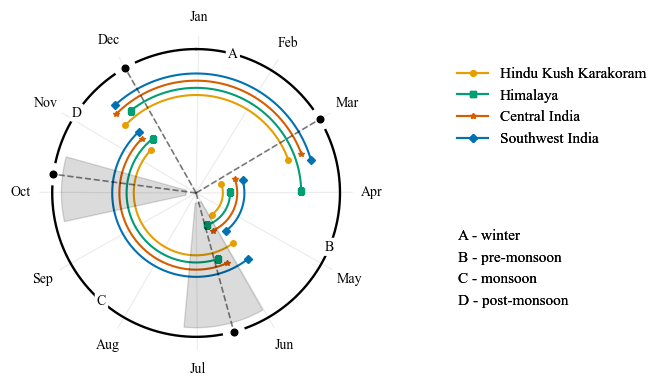

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import mapping
from matplotlib.patches import Wedge
from matplotlib.lines import Line2D

# fill_annular_sector è già definita nel tuo ambiente

season_labels = ['Season 1', 'Season 2', 'Season 3']
region_colors = ['#E69F00', '#009E73', '#D55E00', '#0072B2']  # region palette
region_codes_local = reg_codes
region_markers = ['o', 's', '*', 'D']

FILL_FULL_MONSOON_SLICE = True
MONSOON_FILL_ALPHA = 0.1
MONSOON_EDGE_LW = 1

# === Precompute median start/end for each region and season ===
all_stats = []
n_seas = len(season_labels)
for reg_code in region_codes_local:
    region = gpd.read_file(SHAPEFILES_PATH / f'{reg_code}.gpkg')
    reg_data = clustering_results.rio.clip(region.geometry.apply(mapping))
    seas_stats = []
    for s in range(n_seas):
        start_vals = reg_data.isel(cluster=s).values.flatten()
        start_vals = start_vals[~np.isnan(start_vals)]
        end_idx = (s + 1) % n_seas
        end_vals = reg_data.isel(cluster=end_idx).values.flatten()
        end_vals = end_vals[~np.isnan(end_vals)]
        if start_vals.size == 0 or end_vals.size == 0:
            seas_stats.append({'median_start': np.nan, 'median_end': np.nan})
            continue
        ms = float(np.median(start_vals))
        me_raw = float(np.median(end_vals))
        me = me_raw + 365.0 if me_raw < ms else me_raw
        seas_stats.append({'median_start': ms, 'median_end': me})
    all_stats.append(seas_stats)

# === IMD reference ===
imd_onset_vals = reference_results.isel(cluster=0).date.values.flatten()
imd_with_vals  = reference_results.isel(cluster=1).date.values.flatten()
imd_onset_vals = imd_onset_vals[~np.isnan(imd_onset_vals)]
imd_with_vals  = imd_with_vals[~np.isnan(imd_with_vals)]
if imd_onset_vals.size and imd_with_vals.size:
    imd_start_med = float(np.median(imd_onset_vals))
    imd_end_raw   = float(np.median(imd_with_vals))
    imd_end_med   = imd_end_raw + 365.0 if imd_end_raw < imd_start_med else imd_end_raw
else:
    imd_start_med = imd_end_med = np.nan

# === Figure ===
fig = plt.figure(figsize=(4.5, 4.5))
ax = plt.subplot(111, projection='polar')
fig.subplots_adjust(right=0.72)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2)

season_band_height = 0.55
sub_spacing = 0.015
sub_band_height = (season_band_height - (len(region_codes_local)-1)*sub_spacing) / len(region_codes_local)
base_r0 = 0.4
convert = lambda d: (d / 365.0) * 360.0
max_r_plot = base_r0 + len(season_labels)*(season_band_height + 0.15) + 0.25

# === Archi mediani per regione ===
for seas_idx, seas_label in enumerate(season_labels):
    season_r0 = base_r0 + seas_idx * (season_band_height + 0.15)
    for r_idx, (reg_name, reg_stats, reg_col, reg_marker) in enumerate(zip(reg_names, all_stats, region_colors, region_markers)):
        stats = reg_stats[seas_idx]
        ms = stats['median_start']; me = stats['median_end']
        if np.isnan(ms) or np.isnan(me): continue
        r0 = season_r0 + r_idx * (sub_band_height + sub_spacing)
        r1 = r0 + sub_band_height
        def plot_arc(s_d, e_d, color):
            segs = [(s_d, 365.0), (0.0, e_d % 365.0)] if e_d <= s_d else [(s_d, e_d)]
            for a0, a1 in segs:
                th1 = convert(a0); th2 = convert(a1)
                ax.plot(np.linspace(np.deg2rad(th1), np.deg2rad(th2), 140),
                        np.full(140, r1), color=color, lw=1.5, zorder=2)
        plot_arc(ms, me, reg_col)
        ax.plot([np.deg2rad(convert(ms))], [r0 + sub_band_height], marker=reg_marker,
                color=reg_col, markersize=4, linestyle='None', zorder=3)
        ax.plot([np.deg2rad(convert(me % 365.0))], [r0 + sub_band_height], marker=reg_marker,
                color=reg_col, markersize=4, linestyle='None', zorder=3)

# === Outer reference ring + variabilità IMD (due settori) + A-bis ===
dec1 = 335.0
mar1 = 60.0
apr1 = 91.0  # 1 April
ms = imd_start_med % 365.0
me = imd_end_med   % 365.0
GAP_DAYS = 5

if not np.isnan(ms) and not np.isnan(me):
    r_ref  = max_r_plot + 0.08
    lw_ref = 1.7
    npts   = 220

    # ---- IMD variability bands via fill_annular_sector ----
    if imd_onset_vals.size:
        on_min = float(np.nanmin(imd_onset_vals)) % 365.0
        on_max = float(np.nanmax(imd_onset_vals)) % 365.0
        # banda onset (più interna)
        fill_annular_sector(
            ax, convert(on_min), convert(on_max),
            r_inner=0.2, r_outer=r_ref - 0.18,
            degrees=True, n=300, pad=0.6,
            color='k', alpha=0.14, zorder=4.6
        )
    if imd_with_vals.size:
        wd_min = float(np.nanmin(imd_with_vals)) % 365.0
        wd_max = float(np.nanmax(imd_with_vals)) % 365.0
        # banda withdrawal (poco sotto al cerchio di riferimento)
        fill_annular_sector(
            ax, convert(wd_min), convert(wd_max),
            r_inner=0.2, r_outer=r_ref - 0.18,
            degrees=True, n=300, pad=0.6,
            color='k', alpha=0.14, zorder=4.6
        )

    # ---- helpers per archi reference ----
    def plot_ref_arc(a0, a1, r=r_ref, lw=lw_ref, ls='-', color='k', z=5):
        a0 %= 365.0; a1 %= 365.0
        spans = [(a0, a1)] if a1 > a0 else [(a0, 365.0), (0.0, a1)]
        for w0, w1 in spans:
            th0 = np.deg2rad(convert(w0)); th1 = np.deg2rad(convert(w1))
            thetas = np.linspace(th0, th1, npts)
            ax.plot(thetas, np.full_like(thetas, r), color=color, lw=lw, ls=ls, zorder=z)

    # Segmenti stagionali base (con gap)
    segments = [
        (mar1 + GAP_DAYS, ms - GAP_DAYS),           # B pre-monsoon
        (ms + GAP_DAYS,  me - GAP_DAYS),            # C monsoon
        (me + GAP_DAYS,  dec1 - GAP_DAYS),          # D post-monsoon
        (dec1 + GAP_DAYS, mar1 + 365.0 - GAP_DAYS)  # A winter
    ]
    seg_letters = ['B', 'C', 'D', 'A']
    for (a0, a1) in segments:
        plot_ref_arc(a0, a1)

    # Pallini + linee radiali
    key_points = [mar1, ms, me, dec1]
    for d in key_points:
        th = np.deg2rad(convert(d))
        ax.plot(th, r_ref, 'o', color='k', markersize=4.8, zorder=7)
        ax.plot([th, th], [r_ref - 0.05, r_ref + 0.05], color='k', lw=1.4, ls='--', zorder=6)
        ax.plot([th, th], [0, r_ref], color='k', lw=1.2, ls='--', alpha=0.5, zorder=4)

    # Lettere al centro dei segmenti
    def seg_mid_doy(a0, a1):
        a1c = a1 if a1 >= a0 else a1 + 365.0
        return (a0 + (a1c - a0)/2.0) % 365.0
    for (a0, a1), letter in zip(segments, seg_letters):
        mid_doy = seg_mid_doy(a0, a1)
        th_mid = np.deg2rad(convert(mid_doy))
        ax.text(th_mid, r_ref, letter, ha='center', va='center',
                fontsize=10, zorder=8,
                bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15'))

    # === A-bis: Dec 1 → Apr 1, sopra il winter, collegato con ":" ===
    # r_ref2 = r_ref + 0.22
    # plot_ref_arc(dec1, apr1, r=r_ref2, z=7)
    # for d in [dec1, apr1]:
    #     th = np.deg2rad(convert(d))
    #     ax.plot([th, th], [r_ref, r_ref2], color='k', lw=1.2, ls=':', zorder=7.5)
    # mid_ab = seg_mid_doy(dec1, apr1)
    # th_mid_ab = np.deg2rad(convert(mid_ab))
    # ax.text(th_mid_ab, r_ref2, 'A.bis', ha='center', va='center',
    #         fontsize=9, zorder=9,
    #         bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15'))

# === Assi ===
month_days = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_lab = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax.set_xticks([np.deg2rad(convert(d)) for d in month_days])
ax.set_xticklabels(month_lab, fontsize=10)
ax.set_yticks([])
ax.grid(alpha=0.25)
ax.spines['polar'].set_visible(False)
ax.set_ylim(0, r_ref + 0.25)

# --- legende ---
fig.set_size_inches(6.0, 5.4)
fig.subplots_adjust(right=0.75, bottom=0.30)

legend_elements = []
for reg_name, reg_col, reg_marker in zip(reg_names, region_colors, region_markers):
    handle = Line2D([0,1],[0,0], color=reg_col, marker=reg_marker, markersize=4,
                    lw=1.5, markerfacecolor=reg_col, markeredgecolor=None, label=reg_name)
    legend_elements.append(handle)

leg1 = fig.legend(handles=legend_elements,
                  loc='center left', bbox_to_anchor=(0.85, 0.75),
                  ncol=1, frameon=False, fontsize=11)
fig.add_artist(leg1)

common_handles = [
    Line2D([], [], color='none', label='A - winter'),
    Line2D([], [], color='none', label='B - pre-monsoon'),
    Line2D([], [], color='none', label='C - monsoon'),
    Line2D([], [], color='none', label='D - post-monsoon'),
]
leg2 = fig.legend(handles=common_handles,
                  loc='center left', bbox_to_anchor=(0.78, 0.45),
                  ncol=1, frameon=False, fontsize=11)
fig.add_artist(leg2)

# === Salvataggio ===
tris_path = FIGURES_DIR / 'clustering_results_polar_coverage_all_regions.png'
#fig.savefig(tris_path, dpi=300, bbox_inches='tight', transparent=True)
plt.show()